# 00 — Setup Check ✅
**Companion notebook for the *Python for Geologists* course**

Run every cell in order (`Shift+Enter`, or `Run → Run All Cells`).
If all cells finish with ✅, your environment is ready for the entire course.

> If any cell fails, see the *Troubleshooting Quick Reference* at the end of `02_SETUP_GUIDE.md`.

## 1. Python version
The course works on Python 3.9 or newer (3.11 recommended).

In [1]:
import sys

print("Python version:", sys.version.split()[0])
assert sys.version_info >= (3, 9), "Please install Python 3.9 or newer"
print("✅ Python version OK")

Python version: 3.12.3
✅ Python version OK


## 2. Core scientific libraries
These four libraries power the whole course.

In [2]:
import importlib

libraries = ["numpy", "pandas", "matplotlib", "sklearn"]

for lib in libraries:
    module = importlib.import_module(lib)
    version = getattr(module, "__version__", "unknown")
    print(f"✅ {lib:<12} {version}")

✅ numpy        2.4.4


✅ pandas       3.0.2


✅ matplotlib   3.10.8


✅ sklearn      1.8.0


## 3. Quick functional test
A tiny end-to-end test: make an array, build a table, draw a plot.

Font 'default' does not have a glyph for '\u2705' [U+2705], substituting with a dummy symbol.


class
intermediate    107
felsic           47
mafic            40
ultramafic        6
Name: count, dtype: int64


Font 'default' does not have a glyph for '\u2705' [U+2705], substituting with a dummy symbol.


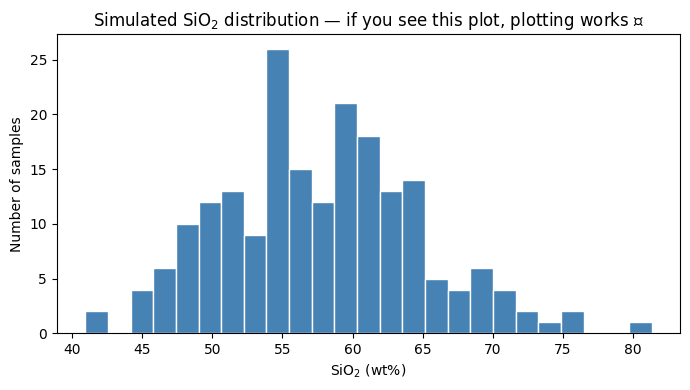

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# NumPy: simulate SiO2 values for 200 volcanic rock samples
rng = np.random.default_rng(42)
sio2 = rng.normal(loc=58, scale=8, size=200)

# Pandas: put them in a table and classify them
df = pd.DataFrame({"SiO2": sio2})
bins   = [0, 45, 52, 63, 100]
labels = ["ultramafic", "mafic", "intermediate", "felsic"]
df["class"] = pd.cut(df["SiO2"], bins=bins, labels=labels)
print(df["class"].value_counts())

# Matplotlib: histogram
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df["SiO2"], bins=25, color="steelblue", edgecolor="white")
ax.set_xlabel("SiO$_2$ (wt%)")
ax.set_ylabel("Number of samples")
ax.set_title("Simulated SiO$_2$ distribution — if you see this plot, plotting works ✅")
plt.tight_layout()
plt.show()

## 4. Course datasets
The course ships three real geological datasets in `content/files/` of the repository
(copied into `data/` in this companion package). This cell finds and loads them.

In [4]:
from pathlib import Path

# Look for the data folder in the usual places
candidates = [Path("../data"), Path("data"),
              Path("../content/files"), Path("files")]
data_dir = next((p for p in candidates if (p / "rocks.csv").exists()), None)
assert data_dir is not None, "Could not find the data folder — check your working directory"
print("Data folder:", data_dir.resolve(), "\n")

rocks  = pd.read_csv(data_dir / "rocks.csv")
assay  = pd.read_csv(data_dir / "assay.csv")
quakes = pd.read_csv(data_dir / "earthquakes.csv")

print(f"✅ rocks.csv       — {rocks.shape[0]:>6} rows × {rocks.shape[1]} cols  (whole-rock geochemistry)")
print(f"✅ assay.csv       — {assay.shape[0]:>6} rows × {assay.shape[1]} cols  (drillhole assays)")
print(f"✅ earthquakes.csv — {quakes.shape[0]:>6} rows × {quakes.shape[1]} cols  (earthquake catalog)")

Data folder: /home/claude/pkg/data 

✅ rocks.csv       —  22437 rows × 10 cols  (whole-rock geochemistry)
✅ assay.csv       —   8332 rows × 11 cols  (drillhole assays)
✅ earthquakes.csv —  18933 rows × 6 cols  (earthquake catalog)


In [5]:
# A first look at each dataset
rocks.head(3)

,Name,SiO2,Al2O3,CaO,Na2O,K2O,FeOT,MgO,MnO,TiO2
0,andesite,62.7,16.9,5.31,4.45,1.57,4.40,3.39,0.05,0.47
1,andesite,61.7,18.9,5.40,5.16,1.65,3.71,2.45,0.03,0.47
2,andesite,62.2,16.9,5.83,4.18,1.87,4.32,3.36,0.07,0.76


In [6]:
assay.head(3)

,ID,FROM,TO,RECOV,CU_pct,AU_gpt,AG_gpt,DENSITY,MO_ppm,AS_ppm,S_pct
0,DH001,0.0,2.0,0.5,0.79,1.75,6.35,NaN,10.0,26.3,0.0
1,DH001,2.0,4.0,1.3,0.83,1.73,5.20,NaN,12.2,31.0,0.0
2,DH001,4.0,6.0,1.8,0.84,6.00,5.75,NaN,24.8,32.5,0.0


In [7]:
quakes.head(3)

,fecha UTC,hora UTC,latitud (º),longitud (º),profundidad (km),magnitud (M)
0,13/01/1960,15:40:34.00,-16.145,-72.144,60,7.5
1,15/01/1960,09:30:24.00,-15.000,-75.000,70,7.0
2,17/01/1960,02:57:58.00,-14.500,-74.500,150,6.4


## 5. All good? 🎉
If every cell above ran without errors, you are fully set up.

**Next steps:**
1. Start the course at `content/0_start.ipynb` in the repository.
2. When you reach the Pandas/Matplotlib chapters, open the second companion notebook
   `01_geology_data_workflow.ipynb` to see a realistic research-style workflow using these same datasets.